<a href="https://colab.research.google.com/github/SREEDEVI555/first_repo/blob/main/Copy_of_emergentcommunication2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import random

In [ ]:
objects=["apple","banana","orange","grape","mango"]
vocab_size=5
num_object=len(objects)
print("Objects: ",objects)
print("Vocabulary symbols:",list(range(vocab_size)))

Objects:  ['apple', 'banana', 'orange', 'grape', 'mango']
Vocabulary symbols: [0, 1, 2, 3, 4]


In [ ]:
sender_policy=np.ones((num_object,vocab_size))
print(sender_policy)


[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]


In [ ]:
reciever_policy=np.ones((vocab_size,num_object))
print(reciever_policy)

[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]


In [ ]:
def choose_symbol(target_index):
  probs=sender_policy[target_index]
  probs=probs/probs.sum()
  return np.random.choice(vocab_size,p=probs)

In [ ]:
episodes = 5000

rewards = []

learning_rate = 0.1

def choose_object(symbol):
  probs=reciever_policy[symbol]
  probs=probs/probs.sum()
  return np.random.choice(num_object,p=probs)

for episode in range(episodes):

    target_index = random.randint(0, num_object - 1);

    symbol = choose_symbol(target_index);

    guess = choose_object(symbol);

    reward = 1 if guess == target_index else 0;

    rewards.append(reward);

    if reward == 1:

        sender_policy[target_index][symbol] += learning_rate;

        reciever_policy[symbol][guess] += learning_rate;

In [ ]:
average_reward = np.mean(rewards)

print("Average Reward:", average_reward)

Average Reward: 0.2772


In [ ]:
print("Sender Policy")

for obj_index, obj in enumerate(objects):

    best_symbol = np.argmax(sender_policy[obj_index])

    print(f"{obj} -> symbol {best_symbol}")

Sender Policy
apple -> symbol 2
banana -> symbol 3
orange -> symbol 0
grape -> symbol 4
mango -> symbol 1


In [ ]:
print("Receiver Policy")

for symbol in range(vocab_size):

    best_object = np.argmax(reciever_policy[symbol])

    print(f"symbol {symbol} -> {objects[best_object]}")

Receiver Policy
symbol 0 -> orange
symbol 1 -> mango
symbol 2 -> apple
symbol 3 -> banana
symbol 4 -> grape


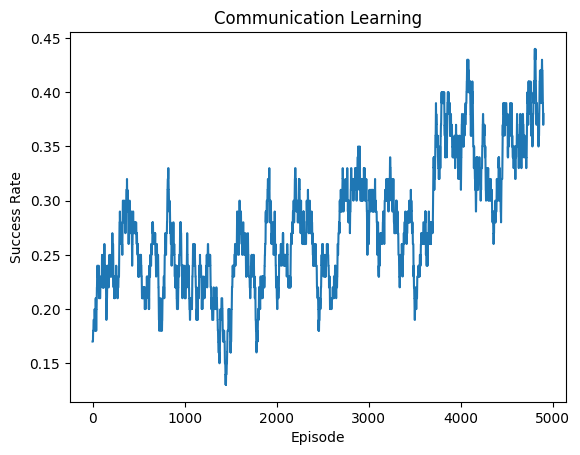

In [ ]:
import matplotlib.pyplot as plt

window = 100

moving_avg = []

for i in range(len(rewards) - window):

    moving_avg.append(
        np.mean(rewards[i:i+window])
    )

plt.plot(moving_avg)

plt.xlabel("Episode")
plt.ylabel("Success Rate")
plt.title("Communication Learning")

plt.show()

In [ ]:
print("Learned Language")
for obj_index,obj in enumerate(objects):
  best_symbol=np.argmax(sender_policy[obj_index])
  print(f"{obj}->Symbol{best_symbol}")

Learned Language
apple->Symbol2
banana->Symbol3
orange->Symbol0
grape->Symbol4
mango->Symbol1
